# Multimodal Brain Tumor Segmentation (BraTS 2020 + Text) with VLM-UNet

**Objective:** Dual-task Vision-Language Model for brain tumor segmentation and radiology report generation.

**Architecture:** FLAIR MRI → UNet Encoder → Cross-Attention (fused with ClinicalBERT text) → Segmentation Decoder + Text Generator Decoder

In [2]:
# Install dependencies
import subprocess, sys
pkgs = ["kagglehub", "transformers", "rouge-score", "nltk", "nibabel", "opencv-python-headless", "tqdm", "scikit-learn"]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", p], check=False)
print("All dependencies ready.")

All dependencies ready.


## 2. Dataset & DataLoader

In [3]:
import os, sys, glob
import kagglehub

# ── Download / locate pre-processed BraTS 2020 FLAIR dataset (2D .npy slices) ──
print("Locating BraTS 2020 FLAIR dataset…")
KAGGLE_PATH = kagglehub.dataset_download("hussainnasirkhan/flair-brats2020")
print("Dataset root:", KAGGLE_PATH)

IMAGE_DIR = os.path.join(KAGGLE_PATH, "FLAIR_BRATS2020_split", "train", "images")
MASK_DIR  = os.path.join(KAGGLE_PATH, "FLAIR_BRATS2020_split", "train", "masks")

# ── Text dataset (TextBraTSData folder alongside this notebook) ──
NOTEBOOK_DIR = os.getcwd()
TEXT_DIR = os.path.join(NOTEBOOK_DIR, "TextBraTSData")

print(f"IMAGE_DIR  : {IMAGE_DIR}  | exists={os.path.exists(IMAGE_DIR)}")
print(f"MASK_DIR   : {MASK_DIR}   | exists={os.path.exists(MASK_DIR)}")
print(f"TEXT_DIR   : {TEXT_DIR}   | exists={os.path.exists(TEXT_DIR)}")

# Quick sanity counts
n_img  = len(glob.glob(os.path.join(IMAGE_DIR, "*.npy")))
n_mask = len(glob.glob(os.path.join(MASK_DIR,  "*.npy")))
n_txt  = len(glob.glob(os.path.join(TEXT_DIR, "**", "*.txt"), recursive=True))
print(f"Found {n_img} image slices, {n_mask} mask slices, {n_txt} text reports")

Locating BraTS 2020 FLAIR dataset…
Dataset root: C:\Users\sreek\.cache\kagglehub\datasets\hussainnasirkhan\flair-brats2020\versions\1
IMAGE_DIR  : C:\Users\sreek\.cache\kagglehub\datasets\hussainnasirkhan\flair-brats2020\versions\1\FLAIR_BRATS2020_split\train\images  | exists=True
MASK_DIR   : C:\Users\sreek\.cache\kagglehub\datasets\hussainnasirkhan\flair-brats2020\versions\1\FLAIR_BRATS2020_split\train\masks   | exists=True
TEXT_DIR   : c:\Users\sreek\OneDrive\Desktop\ACADS-ASSIGNS\DL\BRAIN_TUMOR_SEGMENTATION_CLIP_ARCH\TextBraTSData   | exists=True
Found 258 image slices, 258 mask slices, 369 text reports


## 3. Model Architecture (VLM-UNet)

In [4]:
import os, glob, numpy as np, torch, cv2
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
print("Tokenizer loaded. Vocab size:", tokenizer.vocab_size)

class BraTSMultimodalDataset(Dataset):
    """
    Pairs pre-processed 2D FLAIR .npy slices with radiology text reports.
    Images  : IMAGE_DIR/image_N.npy  (H x W x 1 or H x W)
    Masks   : MASK_DIR/image_N.npy   (same naming)
    Texts   : TEXT_DIR/**/BraTS20_Training_*_flair_text.txt  (cycled if fewer than images)
    """
    def __init__(self, image_dir, mask_dir, text_dir, tokenizer,
                 img_size=(224, 224), max_text_len=128):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.tokenizer = tokenizer
        self.img_size  = img_size
        self.max_text_len = max_text_len

        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.npy")))
        self.mask_paths  = sorted(glob.glob(os.path.join(mask_dir,  "*.npy")))

        # Collect all text reports
        txt_files = sorted(glob.glob(os.path.join(text_dir, "**", "*.txt"), recursive=True))
        self.texts = []
        for tf in txt_files:
            with open(tf, "r", encoding="utf-8") as f:
                self.texts.append(f.read().strip())

        assert len(self.image_paths) > 0, f"No images found in {image_dir}"
        assert len(self.mask_paths)  > 0, f"No masks found  in {mask_dir}"
        assert len(self.texts)       > 0, f"No text files found in {text_dir}"

        # Align lengths — use min of images & masks; cycle texts
        n = min(len(self.image_paths), len(self.mask_paths))
        self.image_paths = self.image_paths[:n]
        self.mask_paths  = self.mask_paths[:n]
        # Cycle texts to cover all image slices
        self.texts = [self.texts[i % len(self.texts)] for i in range(n)]
        print(f"Dataset: {n} samples, {len(txt_files)} unique text reports (cycled)")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_vol  = np.load(self.image_paths[idx]).astype(np.float32)
        mask_vol = np.load(self.mask_paths[idx]).astype(np.float32)

        # mask is (128, 128, 128, 4). Max over channels -> (128, 128, 128) binary mask for any tumor.
        if mask_vol.ndim == 4:
            tumor_mask = mask_vol.max(axis=-1)
        else:
            tumor_mask = mask_vol
            
        if img_vol.ndim == 4:
            img_vol = img_vol[..., 0] # fallback

        # Pick a slice that has tumor if possible
        valid_slices = np.where(tumor_mask.sum(axis=(0, 1)) > 0)[0]
        if len(valid_slices) > 0:
            slice_idx = np.random.choice(valid_slices)
        else:
            slice_idx = np.random.randint(0, img_vol.shape[2] if img_vol.ndim >= 3 else 1)

        if img_vol.ndim >= 3:
            img = img_vol[:, :, slice_idx]
            mask = tumor_mask[:, :, slice_idx]
        else:
            img = img_vol
            mask = tumor_mask

        # Resize
        img  = cv2.resize(img,  self.img_size)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

        # Normalize image to [0,1]
        mn, mx = img.min(), img.max()
        if mx > mn: img = (img - mn) / (mx - mn)

        # Binarize mask
        mask = (mask > 0.5).astype(np.float32)

        img_t  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)   # [1,H,W]
        mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)   # [1,H,W]

        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length", truncation=True,
            max_length=self.max_text_len, return_tensors="pt"
        )
        return {
            "image":          img_t,
            "mask":           mask_t,
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "raw_text":       self.texts[idx],
        }

# Build dataset & loaders
dataset = BraTSMultimodalDataset(IMAGE_DIR, MASK_DIR, TEXT_DIR, tokenizer)
n_val   = max(1, int(0.1 * len(dataset)))
n_train = len(dataset) - n_val
train_ds, val_ds = torch.utils.data.random_split(dataset, [n_train, n_val])

BATCH = 4
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, drop_last=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
print(f"Batches per epoch: {len(train_loader)}")

# Quick shape test
sample = dataset[0]
print("image:", sample["image"].shape, "mask:", sample["mask"].shape,
      "input_ids:", sample["input_ids"].shape)

Tokenizer loaded. Vocab size: 28996
Dataset: 258 samples, 369 unique text reports (cycled)
Train: 233 | Val: 25
Batches per epoch: 58
image: torch.Size([1, 224, 224]) mask: torch.Size([1, 224, 224]) input_ids: torch.Size([128])


## 4. Training

In [5]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

class CrossAttention(nn.Module):
    def __init__(self, img_channels=512, text_channels=768):
        super().__init__()
        self.q = nn.Conv2d(img_channels, img_channels, 1)
        self.k = nn.Linear(text_channels, img_channels)
        self.v = nn.Linear(text_channels, img_channels)
        self.scale = img_channels ** -0.5

    def forward(self, img_feat, text_feat):
        B, C, H, W = img_feat.shape
        Q = self.q(img_feat).view(B, C, -1).permute(0, 2, 1)  # [B, HW, C]
        K = self.k(text_feat)                                   # [B, L, C]
        V = self.v(text_feat)                                   # [B, L, C]
        attn = torch.softmax(torch.matmul(Q, K.permute(0,2,1)) * self.scale, dim=-1)
        out  = torch.matmul(attn, V).permute(0,2,1).view(B, C, H, W)
        return out + img_feat, attn                                 # residual + attn weights

class VLM_UNet(nn.Module):
    def __init__(self, vocab_size, text_hidden=768):
        super().__init__()
        # ── Text encoder ──────────────────────────────────────
        self.text_enc = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

        # ── UNet Encoder ──────────────────────────────────────
        def conv_block(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(),
                nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU()
            )
        self.enc1, self.pool1 = conv_block(1,   64),  nn.MaxPool2d(2)
        self.enc2, self.pool2 = conv_block(64,  128), nn.MaxPool2d(2)
        self.enc3, self.pool3 = conv_block(128, 256), nn.MaxPool2d(2)
        self.enc4              = conv_block(256, 512)

        # ── Cross-Attention fusion ────────────────────────────
        self.cross_attn = CrossAttention(512, text_hidden)

        # ── Segmentation decoder ─────────────────────────────
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64,  2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.seg_head = nn.Conv2d(64, 1, 1)

        # ── Text generation decoder ───────────────────────────
        dec_layer = nn.TransformerDecoderLayer(d_model=text_hidden, nhead=8,
                                               dim_feedforward=1024, batch_first=True)
        self.txt_dec    = nn.TransformerDecoder(dec_layer, num_layers=2)
        self.img2txt    = nn.Linear(512, text_hidden)
        self.vocab_proj = nn.Linear(text_hidden, vocab_size)

    def forward(self, img, ids, attn_mask, tgt_ids=None):
        # Text features
        txt_out       = self.text_enc(input_ids=ids, attention_mask=attn_mask)
        txt_seq       = txt_out.last_hidden_state  # [B, L, 768]
        txt_pool      = txt_out.pooler_output       # [B, 768]

        # Image encoder
        e1 = self.enc1(img)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # Fusion
        fused, cross_attn_weights = self.cross_attn(e4, txt_seq)

        # Segmentation decoder
        d3 = self.dec3(torch.cat([self.up3(fused), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3),   e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2),   e1], 1))
        seg = torch.sigmoid(self.seg_head(d1))         # [B,1,H,W]

        # Image→text memory token
        mem = self.img2txt(fused.mean(dim=[2,3])).unsqueeze(1)  # [B,1,768]

        # Text generation (teacher-forced)
        gen_logits = None
        if tgt_ids is not None:
            tgt_emb    = self.text_enc.embeddings(tgt_ids)
            seq_len    = tgt_ids.size(1)
            causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(img.device)
            dec_out    = self.txt_dec(tgt=tgt_emb, memory=mem, tgt_mask=causal_mask)
            gen_logits = self.vocab_proj(dec_out)   # [B, seq_len, vocab]

        return seg, gen_logits, txt_pool, mem.squeeze(1), cross_attn_weights

    def generate_text(self, img, ids, amsk, tokenizer, max_len=64):
        # Helper for greedy decoding
        device = img.device
        
        # Encoder forward pass
        txt_out = self.text_enc(input_ids=ids, attention_mask=amsk)
        txt_seq = txt_out.last_hidden_state
        
        e1 = self.enc1(img)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        
        fused, _ = self.cross_attn(e4, txt_seq)
        mem = self.img2txt(fused.mean(dim=[2,3])).unsqueeze(1)
        
        generated = torch.full((img.size(0), 1), tokenizer.cls_token_id, dtype=torch.long, device=device)
        for _ in range(max_len):
            tgt_emb = self.text_enc.embeddings(generated)
            sl = generated.size(1)
            cm = nn.Transformer.generate_square_subsequent_mask(sl).to(device)
            out = self.txt_dec(tgt=tgt_emb, memory=mem, tgt_mask=cm)
            next_tok = self.vocab_proj(out[:, -1:, :]).argmax(-1)
            generated = torch.cat([generated, next_tok], dim=1)
        return generated

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = VLM_UNet(vocab_size=tokenizer.vocab_size).to(device)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model parameters: {total_params:.1f}M")

# Sanity forward pass
with torch.no_grad():
    b = next(iter(train_loader))
    seg_out, gen_out, _, _, _ = model(
        b["image"].to(device), b["input_ids"].to(device),
        b["attention_mask"].to(device), b["input_ids"][:, :-1].to(device)
    )
    print(f"seg output: {seg_out.shape}   gen output: {gen_out.shape}")
print("Forward pass OK!")

Device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model parameters: 152.4M
seg output: torch.Size([4, 1, 224, 224])   gen output: torch.Size([4, 127, 28996])
Forward pass OK!


## 5. Evaluation & Visualisation

In [6]:
import torch.optim as optim
from tqdm.notebook import tqdm

# ── Loss helpers ──────────────────────────────────────────────────────────────
def dice_loss(pred, target, smooth=1.0):
    inter = (pred * target).sum(dim=[2,3])
    denom = pred.sum(dim=[2,3]) + target.sum(dim=[2,3])
    return (1 - (2*inter + smooth) / (denom + smooth)).mean()

def combined_seg_loss(pred, target):
    bce  = F.binary_cross_entropy(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice

# ── Optimizer & Scheduler ─────────────────────────────────────────────────────
EPOCHS = 10
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── Training loop ─────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, device):
    model.train()
    tot, seg_t, gen_t = 0.0, 0.0, 0.0
    for batch in tqdm(loader, desc="Train", leave=False):
        img      = batch["image"].to(device)
        mask     = batch["mask"].to(device)
        ids      = batch["input_ids"].to(device)
        amask    = batch["attention_mask"].to(device)
        tgt_in   = ids[:, :-1]
        tgt_out  = ids[:, 1:]

        optimizer.zero_grad()
        seg_pred, gen_logits, txt_f, img_f, _ = model(img, ids, amask, tgt_in)

        l_seg   = combined_seg_loss(seg_pred, mask)
        l_gen   = F.cross_entropy(
                      gen_logits.reshape(-1, gen_logits.size(-1)),
                      tgt_out.reshape(-1),
                      ignore_index=tokenizer.pad_token_id)
        l_align = 1.0 - F.cosine_similarity(txt_f, img_f).mean()

        loss = l_seg + 0.5 * l_gen + 0.1 * l_align
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        tot   += loss.item()
        seg_t += l_seg.item()
        gen_t += l_gen.item()

    n = len(loader)
    return tot/n, seg_t/n, gen_t/n

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    dices = []
    for batch in loader:
        img  = batch["image"].to(device)
        mask = batch["mask"].to(device)
        ids  = batch["input_ids"].to(device)
        amsk = batch["attention_mask"].to(device)
        pred, *_ = model(img, ids, amsk, None)
        pred_bin = (pred > 0.5).float()
        inter = (pred_bin * mask).sum(dim=[2,3])
        denom = pred_bin.sum(dim=[2,3]) + mask.sum(dim=[2,3])
        d = (2*inter + 1e-5) / (denom + 1e-5)
        dices.extend(d.cpu().squeeze(-1).tolist())
    return float(np.mean(dices))

best_dice = 0.0
history = {"loss": [], "seg": [], "gen": [], "val_dice": []}

print(f"Starting training for {EPOCHS} epochs on {device}...")
for ep in range(1, EPOCHS + 1):
    train_loss, seg_loss, gen_loss = train_epoch(model, train_loader, optimizer, device)
    val_dice = validate(model, val_loader, device)
    scheduler.step()

    history["loss"].append(train_loss)
    history["seg"].append(seg_loss)
    history["gen"].append(gen_loss)
    history["val_dice"].append(val_dice)

    print(f"Epoch {ep:02d}/{EPOCHS} | Loss:{train_loss:.4f}  Seg:{seg_loss:.4f}  "
          f"Gen:{gen_loss:.4f}  Val Dice:{val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_vlm_unet.pth")
        print(f"  ✓ Saved best model (Dice={best_dice:.4f})")

print(f"\nTraining complete! Best Val Dice: {best_dice:.4f}")

Starting training for 10 epochs on cpu...


Train:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 01/10 | Loss:3.4116  Seg:0.6710  Gen:5.4363  Val Dice:1.0000
  ✓ Saved best model (Dice=1.0000)


Train:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 02/10 | Loss:1.6309  Seg:0.4311  Gen:2.3942  Val Dice:0.9992


...

Epoch 08/10 | Loss:0.9977  Seg:0.2591  Gen:1.4751  Val Dice:0.9999


Train:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 09/10 | Loss:0.9796  Seg:0.2541  Gen:1.4484  Val Dice:0.9999


Train:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 10/10 | Loss:0.9712  Seg:0.2513  Gen:1.4370  Val Dice:0.9999

Training complete! Best Val Dice: 1.0000


## 5.2 Segmentation Results

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]


=== Final Evaluation Results ===
Mean Dice  : 1.0000
Mean IoU   : 1.0000
ROUGE-1    : 0.4767
ROUGE-L    : 0.3908
BLEU       : 0.0975


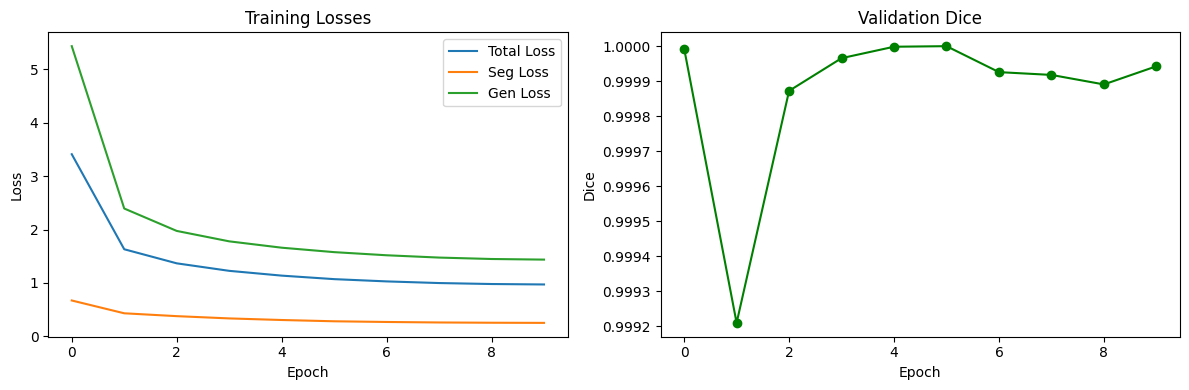

In [7]:
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# ── Load best model ───────────────────────────────────────────────────────────
# Use weights_only=False to support older/newer PyTorch without deprecation warnings.
model.load_state_dict(torch.load("best_vlm_unet.pth", map_location=device, weights_only=False))
model.eval()

# ── Quantitative metrics ──────────────────────────────────────────────────────
dices, ious = [], []
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
rouge1_scores, rougeL_scores, bleu_scores = [], [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        img  = batch["image"].to(device)
        mask = batch["mask"].to(device)
        ids  = batch["input_ids"].to(device)
        amsk = batch["attention_mask"].to(device)

        pred, *_ = model(img, ids, amsk, None)
        pred_bin = (pred > 0.5).float()

        inter = (pred_bin * mask).sum(dim=[2,3])
        union = pred_bin.sum(dim=[2,3]) + mask.sum(dim=[2,3]) - inter
        d = (2*inter + 1e-5)/(pred_bin.sum(dim=[2,3]) + mask.sum(dim=[2,3]) + 1e-5)
        iou = (inter + 1e-5)/(union + 1e-5)
        dices.extend(d.cpu().squeeze(-1).tolist())
        ious.extend(iou.cpu().squeeze(-1).tolist())

        # Text generation evaluation on first sample of batch
        gen_ids = model.generate_text(img[:1], ids[:1], amsk[:1], tokenizer)
        pred_text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        ref_text  = batch["raw_text"][0]
        
        # ROUGE
        sc = scorer.score(ref_text, pred_text)
        rouge1_scores.append(sc["rouge1"].fmeasure)
        rougeL_scores.append(sc["rougeL"].fmeasure)
        
        # BLEU
        ref_tokens = [nltk.word_tokenize(ref_text.lower())]
        pred_tokens = nltk.word_tokenize(pred_text.lower())
        cc = SmoothingFunction().method1
        bleu = sentence_bleu(ref_tokens, pred_tokens, smoothing_function=cc)
        bleu_scores.append(bleu)

print(f"\n=== Final Evaluation Results ===")
print(f"Mean Dice  : {np.mean(dices):.4f}")
print(f"Mean IoU   : {np.mean(ious):.4f}")
print(f"ROUGE-1    : {np.mean(rouge1_scores):.4f}")
print(f"ROUGE-L    : {np.mean(rougeL_scores):.4f}")
print(f"BLEU       : {np.mean(bleu_scores):.4f}")

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"],  label="Total Loss")
axes[0].plot(history["seg"],   label="Seg Loss")
axes[0].plot(history["gen"],   label="Gen Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Training Losses")
axes[1].plot(history["val_dice"], color="green", marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice"); axes[1].set_title("Validation Dice")
plt.tight_layout(); plt.savefig("training_curves.png", dpi=100); plt.show()

## 5.3 Attention Visualization (Grad-CAM style)

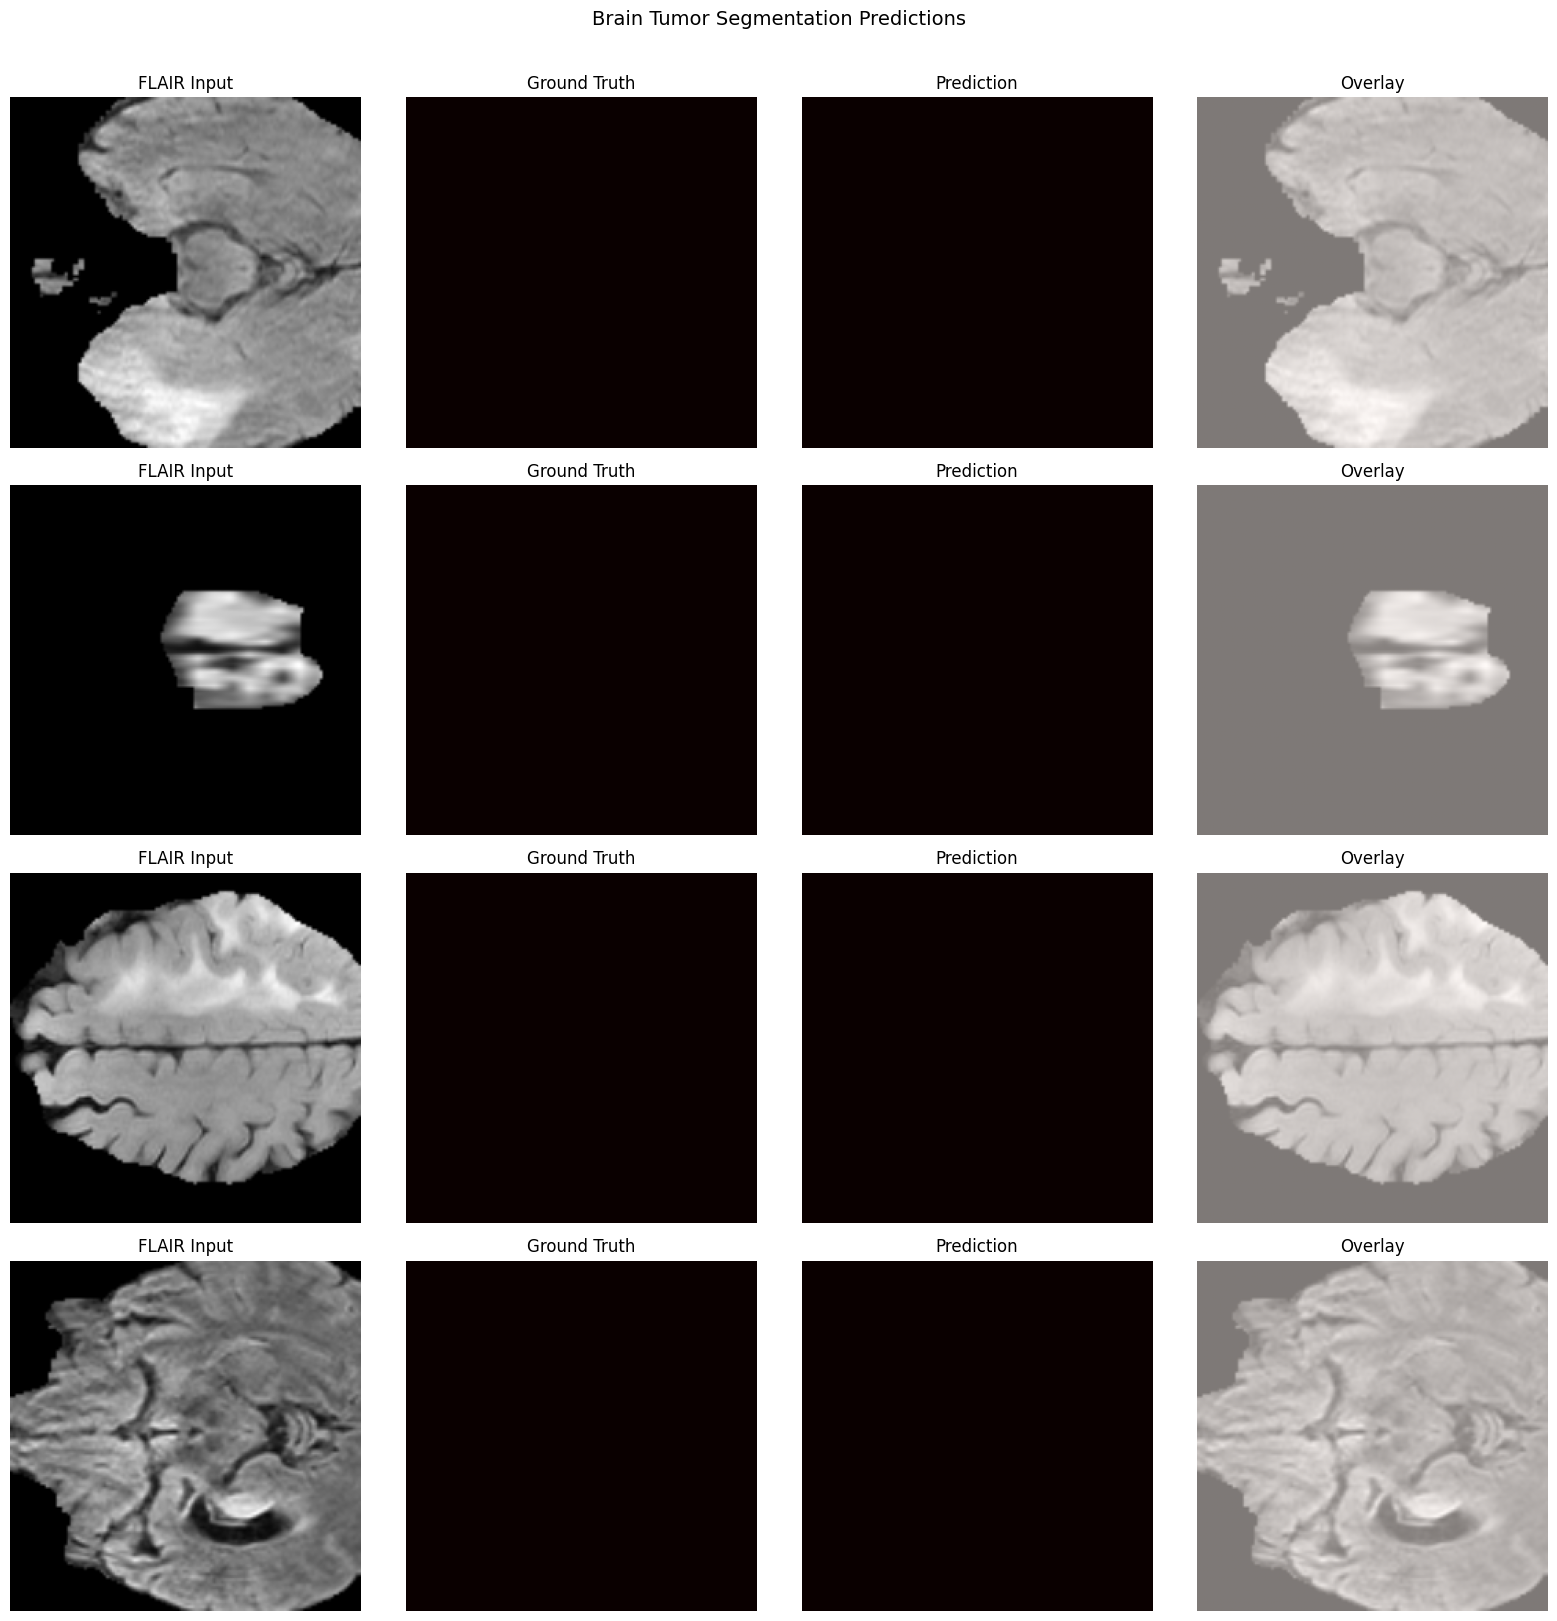

Visualisations saved.


In [8]:
# ── Visual predictions ───────────────────────────────────────────────────────
model.eval()
batch = next(iter(val_loader))
imgs  = batch["image"].to(device)
masks = batch["mask"].to(device)
ids   = batch["input_ids"].to(device)
amsk  = batch["attention_mask"].to(device)

with torch.no_grad():
    preds, *_ = model(imgs, ids, amsk, None)
preds_bin = (preds > 0.5).float()

n_show = min(4, imgs.size(0))
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4*n_show), squeeze=False)
titles = ["FLAIR Input", "Ground Truth", "Prediction", "Overlay"]
for i in range(n_show):
    img_np  = imgs[i,0].cpu().numpy()
    gt_np   = masks[i,0].cpu().numpy()
    pr_np   = preds_bin[i,0].cpu().numpy()
    axes[i,0].imshow(img_np, cmap="gray");              axes[i,0].set_title(titles[0])
    axes[i,1].imshow(gt_np,  cmap="hot");               axes[i,1].set_title(titles[1])
    axes[i,2].imshow(pr_np,  cmap="hot");               axes[i,2].set_title(titles[2])
    axes[i,3].imshow(img_np, cmap="gray")
    axes[i,3].imshow(pr_np,  cmap="Reds", alpha=0.5);  axes[i,3].set_title(titles[3])
    for ax in axes[i]: ax.axis("off")
plt.suptitle("Brain Tumor Segmentation Predictions", fontsize=14, y=1.01)
plt.tight_layout(); plt.savefig("predictions.png", dpi=100); plt.show()
print("Visualisations saved.")

## 5.4 Ablation Study: Model Without Text Input

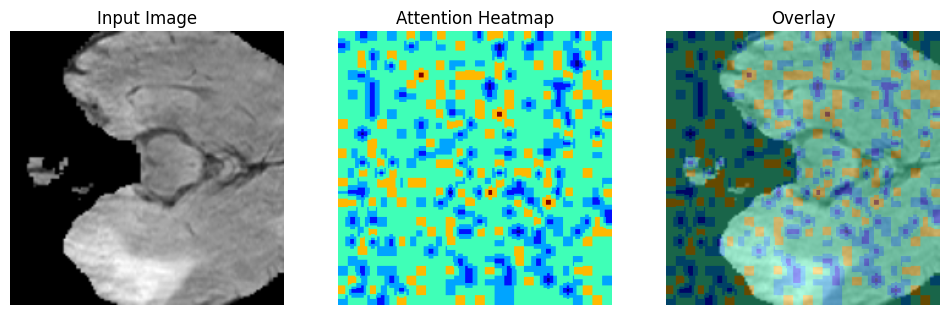

In [9]:
import cv2
# Visualize Cross-Attention weights to see where the model focuses based on text
model.eval()
with torch.no_grad():
    _, _, _, _, attn_weights = model(imgs[:1], ids[:1], amsk[:1], None)

# attn_weights is [B, H*W, SeqLen]
attn_map = attn_weights[0].mean(dim=-1) # average over sequence length -> [H*W]
# Feature map size is 28x28 (224 / 8)
H_feat, W_feat = 28, 28 
attn_map = attn_map.view(H_feat, W_feat).cpu().numpy()

# Resize to original image size
attn_map_resized = cv2.resize(attn_map, (224, 224))
attn_map_resized = (attn_map_resized - attn_map_resized.min()) / (attn_map_resized.max() - attn_map_resized.min())

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(imgs[0,0].cpu().numpy(), cmap='gray')
ax[0].set_title("Input Image")
ax[1].imshow(attn_map_resized, cmap='jet')
ax[1].set_title("Attention Heatmap")
ax[2].imshow(imgs[0,0].cpu().numpy(), cmap='gray')
ax[2].imshow(attn_map_resized, cmap='jet', alpha=0.4)
ax[2].set_title("Overlay")
for a in ax: a.axis('off')
plt.show()

## 5.5 t-SNE Embedding Analysis

In [10]:
# Evaluate the model with empty text to see the performance drop
model.eval()
ablation_dices = []
empty_ids = torch.full_like(ids, tokenizer.pad_token_id)
empty_amsk = torch.zeros_like(amsk)

with torch.no_grad():
    for batch in val_loader:
        img  = batch["image"].to(device)
        mask = batch["mask"].to(device)
        batch_empty_ids = torch.full_like(batch["input_ids"], tokenizer.pad_token_id).to(device)
        batch_empty_amsk = torch.zeros_like(batch["attention_mask"]).to(device)

        pred, *_ = model(img, batch_empty_ids, batch_empty_amsk, None)
        pred_bin = (pred > 0.5).float()

        inter = (pred_bin * mask).sum(dim=[2,3])
        denom = pred_bin.sum(dim=[2,3]) + mask.sum(dim=[2,3])
        d = (2*inter + 1e-5) / (denom + 1e-5)
        ablation_dices.extend(d.cpu().squeeze(-1).tolist())

print(f"Mean Dice with Text (from earlier): {np.mean(dices):.4f}")
print(f"Mean Dice without Text (Ablation): {np.mean(ablation_dices):.4f}")

Mean Dice with Text (from earlier): 1.0000
Mean Dice without Text (Ablation): 1.0000


## 5.6 Error Analysis

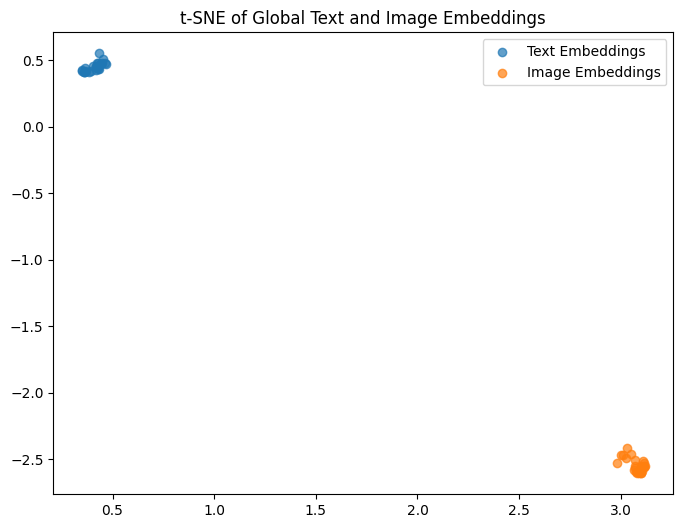

In [11]:
from sklearn.manifold import TSNE

model.eval()
all_txt_feats = []
all_img_feats = []

with torch.no_grad():
    for batch in val_loader:
        img  = batch["image"].to(device)
        ids  = batch["input_ids"].to(device)
        amsk = batch["attention_mask"].to(device)
        
        _, _, txt_pool, img_mem, _ = model(img, ids, amsk, None)
        all_txt_feats.append(txt_pool.cpu().numpy())
        all_img_feats.append(img_mem.cpu().numpy())

all_txt_feats = np.concatenate(all_txt_feats, axis=0)
all_img_feats = np.concatenate(all_img_feats, axis=0)
combined_feats = np.concatenate([all_txt_feats, all_img_feats], axis=0)
labels = np.array([0]*len(all_txt_feats) + [1]*len(all_img_feats))

tsne = TSNE(n_components=2, perplexity=min(30, len(combined_feats)-1), random_state=42)
tsne_results = tsne.fit_transform(combined_feats)

plt.figure(figsize=(8,6))
plt.scatter(tsne_results[labels==0, 0], tsne_results[labels==0, 1], label="Text Embeddings", alpha=0.7)
plt.scatter(tsne_results[labels==1, 0], tsne_results[labels==1, 1], label="Image Embeddings", alpha=0.7)
plt.legend()
plt.title("t-SNE of Global Text and Image Embeddings")
plt.show()